In [1]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #bee7ff; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #1e1a66">Reduced Order Modeling on Stokes Equations</h3>
</div>

Imports:

In [2]:
from scipy.sparse.linalg import spsolve
import numpy as np

from Utilities.Stokes_felib import *
from Utilities.Mesh_processing import *
from Utilities.Plot_functions import *

---

In [3]:
p_coarse, e_coarse, t_coarse = Plot_Initial_Refined_meshes(data_path='Meshes/exchanger_device_altered_mesh_data.npz', num_of_refinements=3, 
                                                           plot=False,
                                                           figsize=(16,4))
p_fine, e_fine, t_fine = refine(p_coarse, e_coarse, t_coarse)

### Check the Viscosity Snapshots

--- GLOBAL STATISTICS ---
Total Snapshots:      100
Elements per Mesh:    191488
Absolute Min ( >0? ): 10.242768
Absolute Max:         199.898669
Global Mean:          104.964117

--- SPATIAL VARIABILITY ---
Highest variability at element 97408 (Std: 54.903198)
Lowest variability is 29.664079

--- INTRINSIC DIMENSIONALITY ---
Modes needed to capture 99.9% of viscosity variance: 5


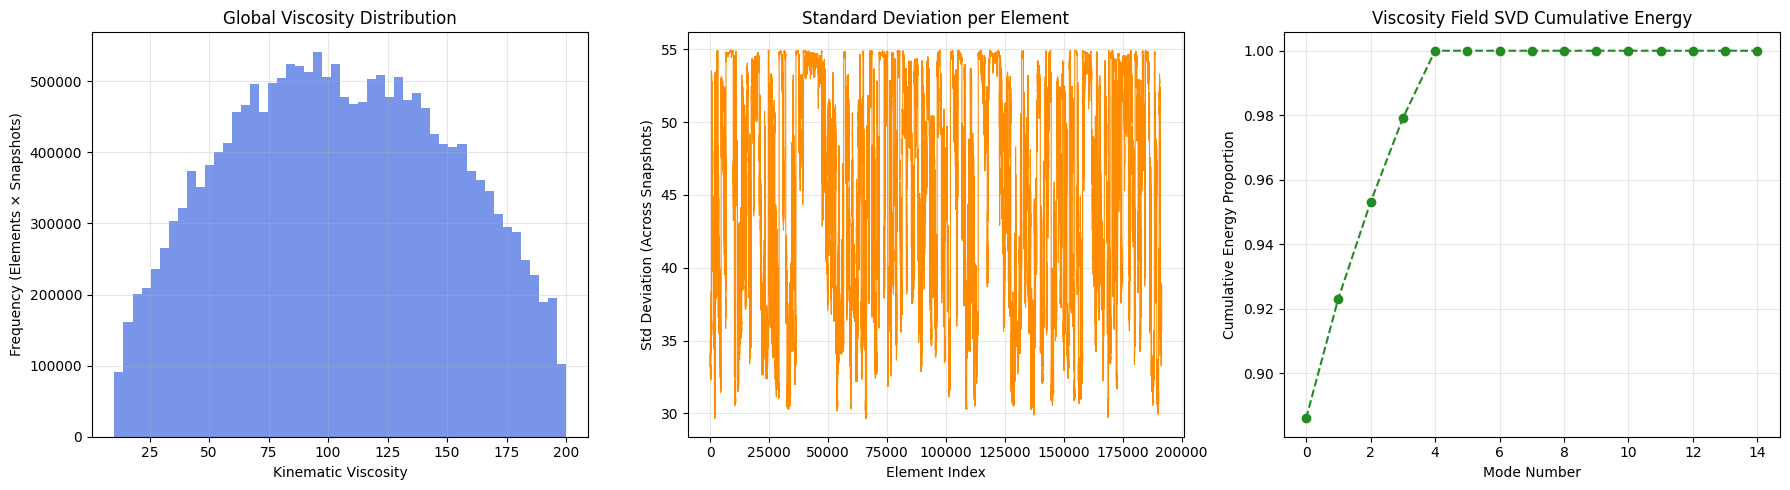

In [9]:
# 1. Load Data
npz_path = os.path.join('Reduced_Order_Modeling', 'Data', 'viscosity_snapshots.npz')
with np.load(npz_path) as data:
    v_t = data['v_t_snapshots']  # Shape expected: (n_snapshots, n_elements)

n_snapshots, n_elements = v_t.shape

# ---------------------------------------------------------
# 2. Global Statistics (Sanity Checks)
# ---------------------------------------------------------
print("--- GLOBAL STATISTICS ---")
print(f"Total Snapshots:      {n_snapshots}")
print(f"Elements per Mesh:    {n_elements}")
print(f"Absolute Min ( >0? ): {np.min(v_t):.6f}")
print(f"Absolute Max:         {np.max(v_t):.6f}")
print(f"Global Mean:          {np.mean(v_t):.6f}")

# ---------------------------------------------------------
# 3. Spatial Variance (Where does the field change most?)
# ---------------------------------------------------------
element_std = np.std(v_t, axis=0)
max_var_elem = np.argmax(element_std)

print("\n--- SPATIAL VARIABILITY ---")
print(f"Highest variability at element {max_var_elem} (Std: {np.max(element_std):.6f})")
print(f"Lowest variability is {np.min(element_std):.6f}")

# ---------------------------------------------------------
# 4. Dimensionality / Complexity (ROM prep)
# ---------------------------------------------------------
# Performing SVD on the parameter field reveals its mathematical rank.
# Because your field is built using 5 knots, the rank should be low.
_, S, _ = np.linalg.svd(v_t, full_matrices=False)
energy = np.cumsum(S**2) / np.sum(S**2)
modes_99 = np.searchsorted(energy, 0.999) + 1

print("\n--- INTRINSIC DIMENSIONALITY ---")
print(f"Modes needed to capture 99.9% of viscosity variance: {modes_99}")

# ---------------------------------------------------------
# 5. Visualizations
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Overall Distribution
axes[0].hist(v_t.flatten(), bins=50, color='royalblue', alpha=0.7)
axes[0].set_title("Global Viscosity Distribution")
axes[0].set_xlabel("Kinematic Viscosity")
axes[0].set_ylabel("Frequency (Elements × Snapshots)")
axes[0].grid(alpha=0.3)

# Plot B: Spatial Variability
axes[1].plot(element_std, color='darkorange', linewidth=0.8)
axes[1].set_title("Standard Deviation per Element")
axes[1].set_xlabel("Element Index")
axes[1].set_ylabel("Std Deviation (Across Snapshots)")
axes[1].grid(alpha=0.3)

# Plot C: Singular Value Decay
axes[2].plot(energy[:15], marker='o', color='forestgreen', linestyle='--')
axes[2].set_title("Viscosity Field SVD Cumulative Energy")
axes[2].set_xlabel("Mode Number")
axes[2].set_ylabel("Cumulative Energy Proportion")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

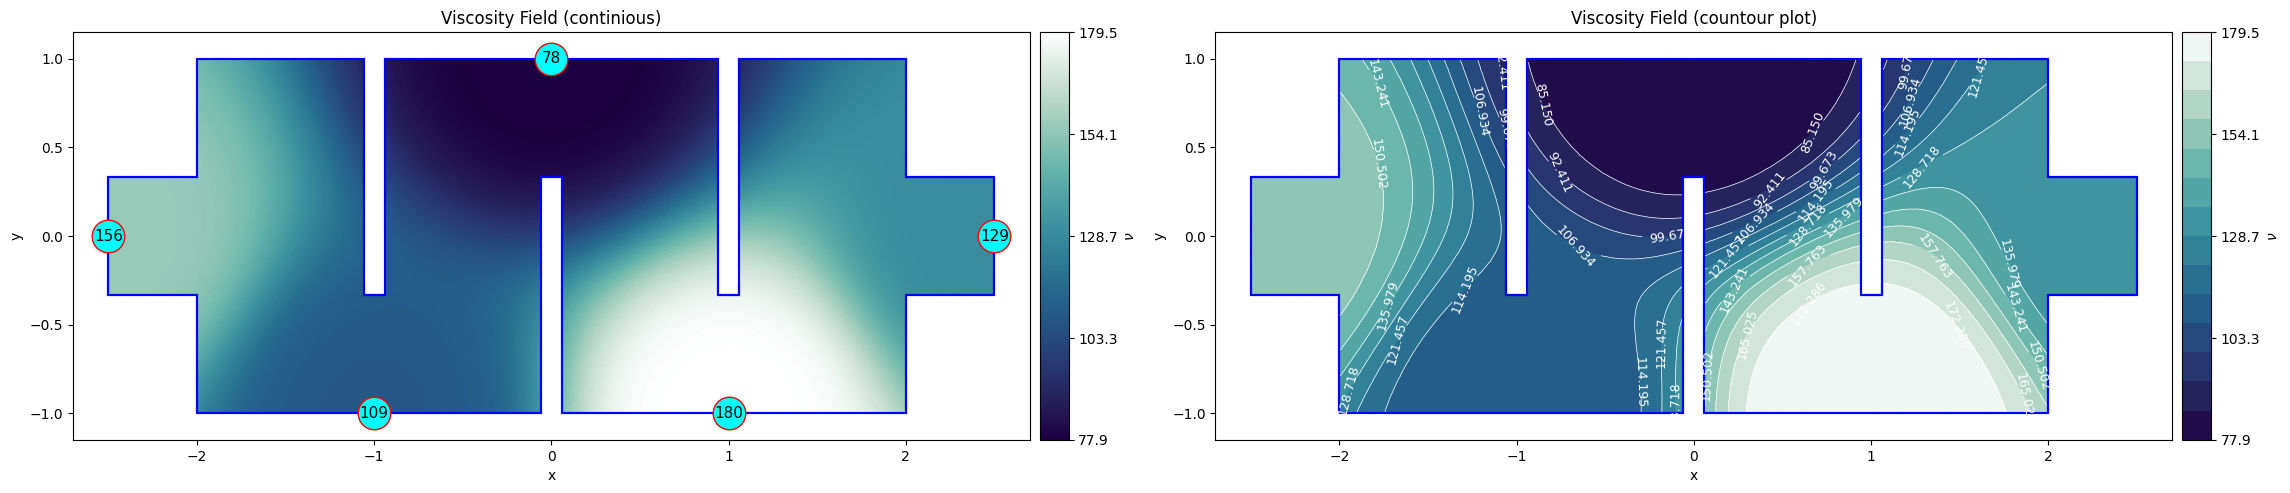

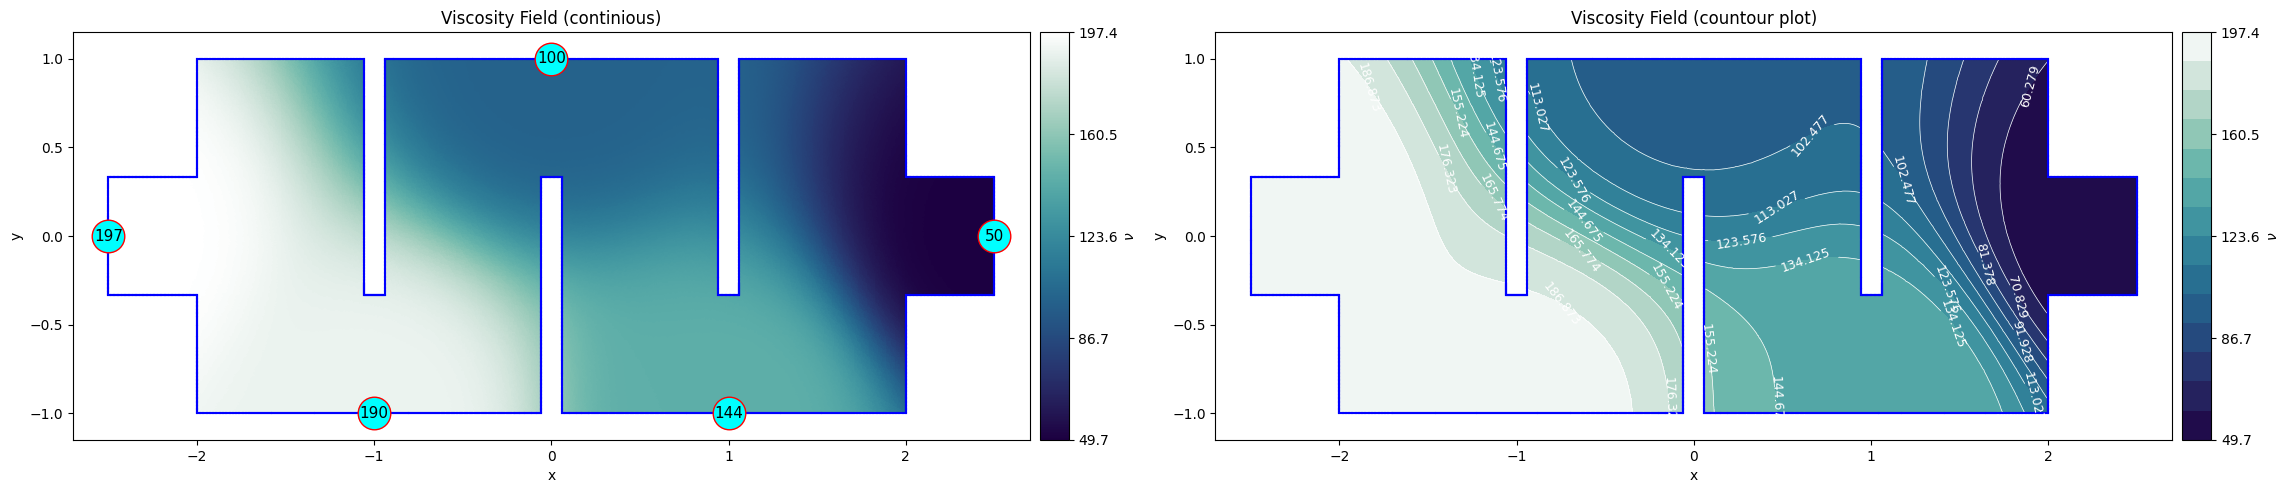

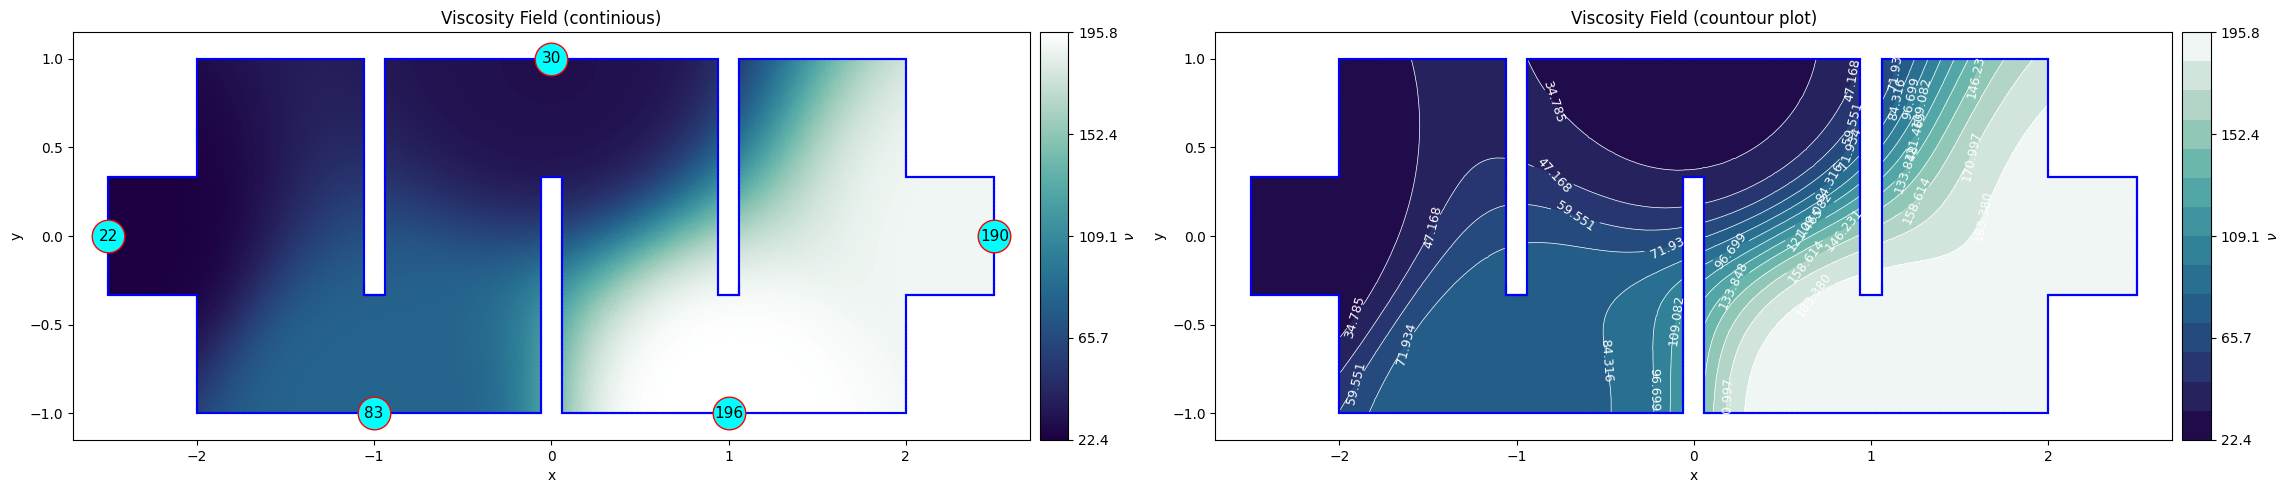

In [8]:
npz_path = os.path.join('Reduced_Order_Modeling', 'Data', 'viscosity_snapshots.npz')
data = np.load(npz_path)

p_fine = data['p_fine']
t_fine = data['t_fine']
e_fine = data['e_fine']
knots  = data['knots']

for snapshot_idx in [3, 7, 9]:
    v_t_snapshot = data['v_t_snapshots'][snapshot_idx]
    params_snapshot = data['parameters'][snapshot_idx]

    nu_KNOTS = {
        'pts': knots,
        'vals': params_snapshot
    }

    plot_viscosity(p_fine, t_fine, e_fine, v_t_snapshot, nu_KNOTS,
                n_levels=15,
                figsize=(23, 10),
                savetype='png')

data.close()


---

In [ ]:
def compute_U_P_solution(p_fine, t_fine, e_fine, p_coarse, t_coarse,
                         inlet_velocity: float = 1.0,
                         kinematic_viscosity: float = 0.01):

    Nv = p_fine.shape[0]
    Np = p_coarse.shape[0]
    eps = 1e-10   

    xmin = p_fine[:, 0].min()
    xmax = p_fine[:, 0].max()

    inlet_idx  = np.where(np.abs(p_fine[:, 0] - xmin) < eps)[0]
    outlet_idx = np.where(np.abs(p_fine[:, 0] - xmax) < eps)[0]

    boundary_nodes = np.unique(e_fine[e_fine[:, 2] > 0, 0:2])
    v_wall_idx = np.setdiff1d(boundary_nodes, np.concatenate([inlet_idx, outlet_idx]))
    dirichlet_nodes = np.unique(np.concatenate([inlet_idx, v_wall_idx]))

    lf_x = np.zeros(Nv)
    lf_y = np.zeros(Nv)
    lf_x[inlet_idx] = inlet_velocity          

    A  = calculate_velocity_A(p_fine, t_fine, kinematic_viscosity)
    Bx, By = calculate_pressure_B(p_fine, t_fine, p_coarse, t_coarse)
    K  = calculate_Saddle_point_K(A, Bx, By)

    F = np.zeros(2 * Nv + Np)
    F[:Nv]    -= A.dot(lf_x)
    F[2*Nv:]  -= Bx.dot(lf_x)  

    print(f"K is of the shape {K.shape}")

    K = K.tolil()

    for i in dirichlet_nodes:
        K[i, :]  = 0.0
        K[i, i]  = 1.0
        F[i]     = 0.0

        iy = i + Nv
        K[iy, :] = 0.0
        K[iy, iy] = 1.0
        F[iy]    = 0.0

    is_outlet_p = np.abs(p_coarse[:, 0] - xmax) < eps
    p_ref_idx   = np.where(is_outlet_p)[0]

    if len(p_ref_idx) == 0:
        p_ref_idx = [np.argmin(np.abs(p_coarse[:, 0] - xmax))]
        print("Warning: no coarse node exactly on outlet x; using nearest.")

    p_row = 2 * Nv + p_ref_idx[0]
    K[p_row, :] = 0.0
    K[p_row, p_row] = 1.0
    F[p_row] = 0.0        

    # ------------------------------------------------------------------
    # Solve
    # ------------------------------------------------------------------
    print("Solving lifted system...")
    sol = spsolve(K.tocsc(), F)

    if np.any(np.isnan(sol)):
        raise RuntimeError("NaNs in solution — check mesh connectivity and BCs.")

    u0_x     = sol[:Nv]
    u0_y     = sol[Nv:2*Nv]
    pressure = sol[2*Nv:]

    # Recover full velocity
    ux = u0_x + lf_x
    uy = u0_y + lf_y

    # ------------------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------------------
    div = Bx @ ux + By @ uy
    print(f"||div u|| = {np.linalg.norm(div):.3e}")
    print(f"max |div| = {np.max(np.abs(div)):.3e}")
    print(f"pressure  min/mean/max = "
          f"{pressure.min():.4f} / {pressure.mean():.4f} / {pressure.max():.4f}")

    return ux, uy, pressure


In [ ]:
ux, uy, p_sol = compute_U_P_solution(p_fine, t_fine, e_fine, p_coarse, t_coarse, 1, v_t)

save_simulation_data(p_fine, e_fine, t_fine, 
                    p_coarse, e_coarse, t_coarse, 
                    ux, uy, p_sol,
                    name='Exchanger_device_with_varying_viscosity')

K is of the shape (218107, 218107)
Solving lifted system...
||div u|| = 3.387e-05
max |div| = 3.387e-05
pressure  min/mean/max = -24534.4559 / 12320.3237 / 30888.3053
Simulation 'Exchanger_device_with_varying_viscosity' data saved.


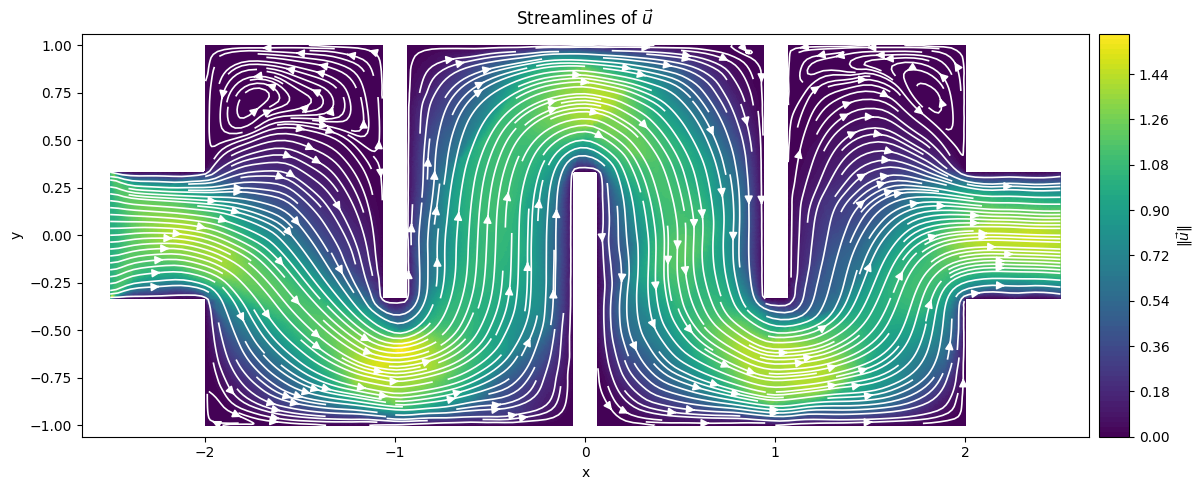

In [ ]:
plot_streamlines(p_fine, t_fine, ux, uy,
                 grid_num=(500,500),
                 figsize=(15,5),
                 density=3.7)

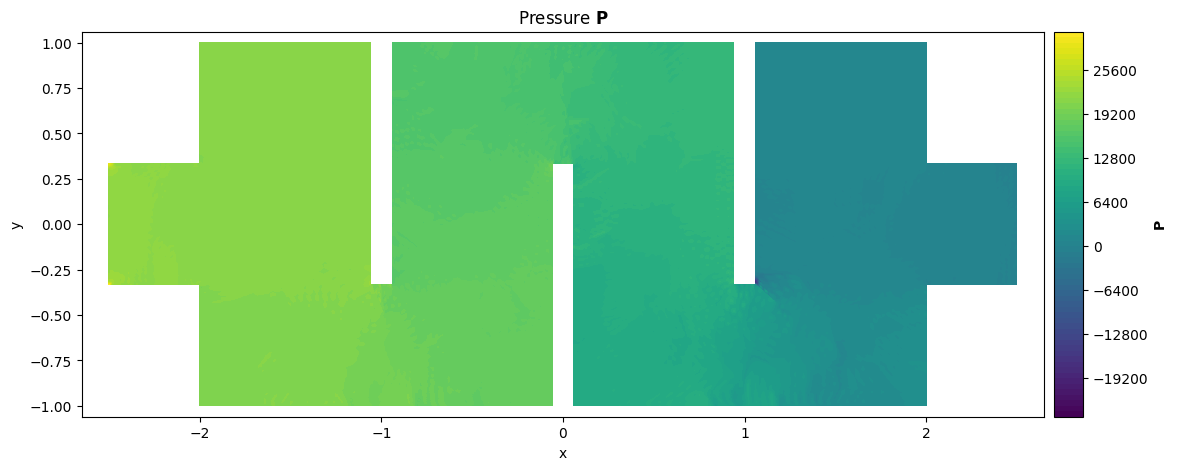

In [ ]:
plot_pressure(p_coarse, t_coarse, p_sol,
              figsize=(15,5))

### Solution Snapshots

Loading snapshot database...

 GLOBAL FIELD STATISTICS
 Total Snapshots:     100
--------------------------------------------------
 Velocity Mag Min:    0.000000
 Velocity Mag Max:    1.605584
 Velocity Mag Mean:   0.565803
--------------------------------------------------
 Pressure Min:        -60451.14
 Pressure Max:        272753.39
 Pressure Mean:       29020.09

Computing Singular Value Decomposition (SVD)...

 ROM ENERGY REQUIREMENTS
 Velocity Modes for 99.9% Energy:   3
 Velocity Modes for 99.99% Energy:  5
--------------------------------------------------
 Pressure Modes for 99.9% Energy:   4
 Pressure Modes for 99.99% Energy:  5


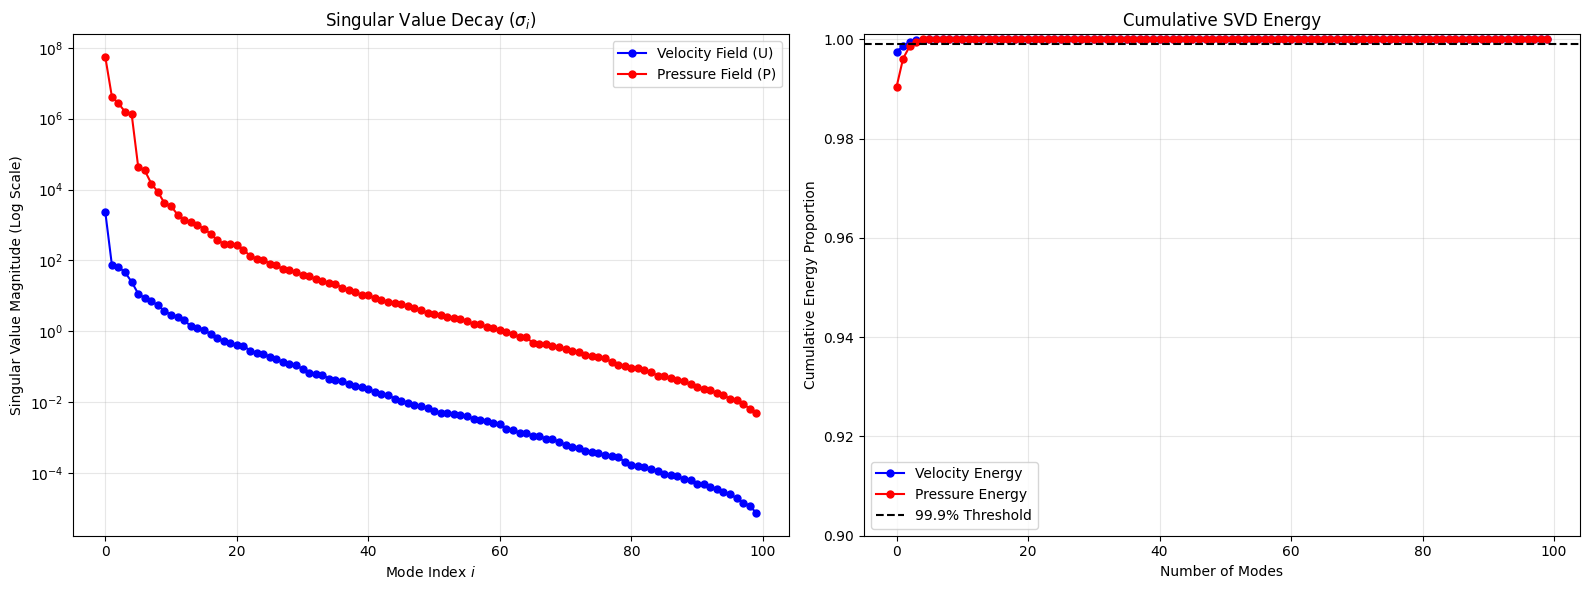

In [3]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────────────────────────────────────
# 1. Environment & Path Resolution
# ──────────────────────────────────────────────────────────────────────────────
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
fem_dir = os.path.dirname(script_dir) if 'Demonstrations' in script_dir or 'Reduced_Order_Modeling' in script_dir else script_dir

npz_path = os.path.join(fem_dir, 'Reduced_Order_Modeling', 'Data', 'stokes_solution_snapshots.npz')

# ──────────────────────────────────────────────────────────────────────────────
# 2. Load the Data
# ──────────────────────────────────────────────────────────────────────────────
print("Loading snapshot database...")
with np.load(npz_path) as data:
    ux = data['ux_snapshots']
    uy = data['uy_snapshots']
    p  = data['p_snapshots']

num_snapshots, Nv = ux.shape
_, Np = p.shape

# Calculate Velocity Magnitude field for all snapshots
U_mag = np.sqrt(ux**2 + uy**2)

# ──────────────────────────────────────────────────────────────────────────────
# 3. Global Statistics & Spatial Variance
# ──────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 50)
print(" GLOBAL FIELD STATISTICS")
print("=" * 50)
print(f" Total Snapshots:     {num_snapshots}")
print("-" * 50)
print(f" Velocity Mag Min:    {np.min(U_mag):.6f}")
print(f" Velocity Mag Max:    {np.max(U_mag):.6f}")
print(f" Velocity Mag Mean:   {np.mean(U_mag):.6f}")
print("-" * 50)
print(f" Pressure Min:        {np.min(p):.2f}")
print(f" Pressure Max:        {np.max(p):.2f}")
print(f" Pressure Mean:       {np.mean(p):.2f}")
print("=" * 50)

# ──────────────────────────────────────────────────────────────────────────────
# 4. Intrinsic Dimensionality (SVD Energy Decay)
# ──────────────────────────────────────────────────────────────────────────────
print("\nComputing Singular Value Decomposition (SVD)...")

# To perform SVD on vectors, we stack ux and uy into a single state matrix per snapshot
# Shape: (num_snapshots, 2 * Nv)
U_state_matrix = np.hstack([ux, uy])

# Economy SVD (Only computes up to num_snapshots singular values)
_, S_U, _ = np.linalg.svd(U_state_matrix, full_matrices=False)
_, S_P, _ = np.linalg.svd(p, full_matrices=False)

# Calculate Cumulative Energy Proportion
energy_U = np.cumsum(S_U**2) / np.sum(S_U**2)
energy_P = np.cumsum(S_P**2) / np.sum(S_P**2)

# Find how many modes are needed for 99.9% and 99.99% energy
modes_U_999 = np.searchsorted(energy_U, 0.999) + 1
modes_U_9999 = np.searchsorted(energy_U, 0.9999) + 1

modes_P_999 = np.searchsorted(energy_P, 0.999) + 1
modes_P_9999 = np.searchsorted(energy_P, 0.9999) + 1

print("\n" + "=" * 50)
print(" ROM ENERGY REQUIREMENTS")
print("=" * 50)
print(f" Velocity Modes for 99.9% Energy:   {modes_U_999}")
print(f" Velocity Modes for 99.99% Energy:  {modes_U_9999}")
print("-" * 50)
print(f" Pressure Modes for 99.9% Energy:   {modes_P_999}")
print(f" Pressure Modes for 99.99% Energy:  {modes_P_9999}")
print("=" * 50)

# ──────────────────────────────────────────────────────────────────────────────
# 5. Visualizations
# ──────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Singular Value Decay (Log Scale)
axes[0].plot(S_U, 'bo-', label='Velocity Field (U)', markersize=5)
axes[0].plot(S_P, 'ro-', label='Pressure Field (P)', markersize=5)
axes[0].set_yscale('log')
axes[0].set_title('Singular Value Decay ($\\sigma_i$)')
axes[0].set_xlabel('Mode Index $i$')
axes[0].set_ylabel('Singular Value Magnitude (Log Scale)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Plot B: Cumulative Energy
axes[1].plot(energy_U, 'bo-', label='Velocity Energy', markersize=5)
axes[1].plot(energy_P, 'ro-', label='Pressure Energy', markersize=5)
axes[1].axhline(0.999, color='k', linestyle='--', label='99.9% Threshold')
axes[1].set_title('Cumulative SVD Energy')
axes[1].set_xlabel('Number of Modes')
axes[1].set_ylabel('Cumulative Energy Proportion')
axes[1].set_ylim([0.9, 1.001])  # Zoom in on the top 10%
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()